Date: 03/01/2024 <br>
Des: Plot metrics for broadcast protocols

## Plot histogram of broadcasts and packet receptions,

Total DL Broadcasts: 145
Total DL No. Packets Rcvd: 489


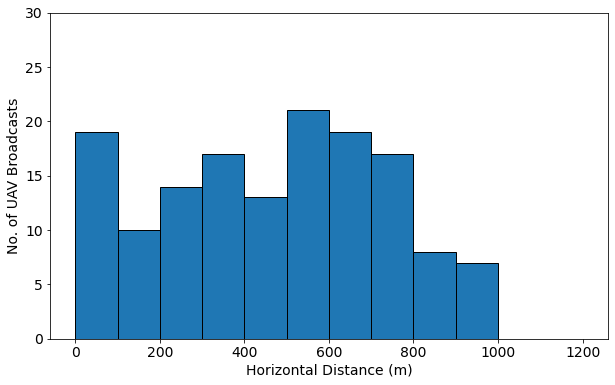

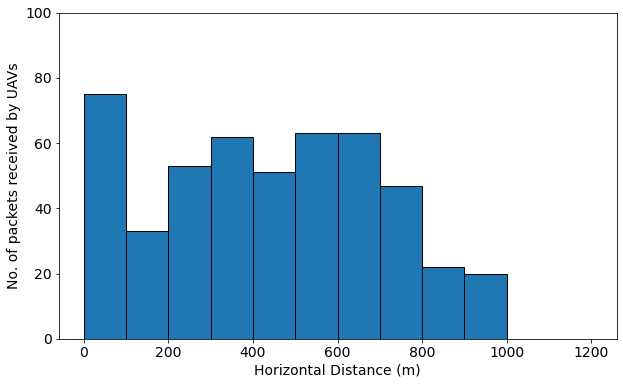

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob, os

# Get data 
sim_root_path = "/media/research-student/One Touch/FANET Datasets/DJISpark_ReBroadcast_Protocols_Test/fixedProb-0.5_CT-3/UAVSpeed-12_BitRate-13_Height-270_Distance-1200_Modulation-QPSK_UAVSendingInterval-1000_CounterThreshold-3"
scenario_files = glob.glob(sim_root_path + "/*.csv")
gcs_br_file = [file for file in scenario_files if (('_GCS-Broadcast' in file))]
gw_rx_file = [file for file in scenario_files if (('_GW-Rx' in file))]
gw_br_file = [file for file in scenario_files if (('_GW-Broadcast' in file))]
uav_rx_files = [file for file in scenario_files if (('_UAV-' in file) and ('-Rx.csv' in file))]
uav_br_files = [file for file in scenario_files if (('_UAV-' in file) and ('-Broadcast.csv' in file))]
if len(gcs_br_file) > 0:
    gcs_br_df = pd.read_csv(gcs_br_file[0])
gw_br_df = pd.read_csv(gw_br_file[0])
gw_rx_df = pd.read_csv(gw_rx_file[0])
uavs_rx_df_list = []
for uav_rx_file in uav_rx_files:
    uav_rx_df = pd.read_csv(uav_rx_file)
    uav_rx_df = uav_rx_df.sort_values(["Packet_Name", "RxTime"], ascending=[True, True])
    uav_rx_df = uav_rx_df.drop_duplicates(subset='Packet_Name', keep="first")
    uavs_rx_df_list.append(uav_rx_df)
uavs_br_df_list = []
for uav_br_file in uav_br_files:
    uavs_br_df_list.append(pd.read_csv(uav_br_file))
dl_rx_df = pd.concat([gw_rx_df]+uavs_rx_df_list)
dl_br_df = pd.concat([gw_br_df]+uavs_br_df_list)

# Get horizontal distance data
uav_speed = 12
if len(gcs_br_file) > 0:
    gcs_br_df["Horizontal_Distance"] = gcs_br_df["TxTime"] * uav_speed
dl_br_df["Horizontal_Distance"] = dl_br_df["TxTime"] * uav_speed
dl_rx_df["Horizontal_Distance"] = dl_rx_df["RxTime"] * uav_speed

# Filter delay exceeded packets
delay_th = 1
dl_rx_df["Delay"] = dl_rx_df["RxTime"] - dl_rx_df["TxTime"]
dl_rx_df = dl_rx_df.loc[dl_rx_df["Delay"]<=delay_th]

# Plot histogram of UAV broadcast occurences
countsBr, binsBr = np.histogram(dl_br_df["Horizontal_Distance"], bins=12, range=(0,1200))
plt.figure(figsize=(10,6))
plt.rcParams.update({'font.size': 14})
plt.hist(binsBr[:-1], binsBr, weights=countsBr, edgecolor='black')
plt.ylim(0, 30)
plt.xlabel("Horizontal Distance (m)")
plt.ylabel("No. of UAV Broadcasts")

# Plot histogram of GCS broadcast occurences
if len(gcs_br_file) > 0:
    countsBr, binsBr = np.histogram(gcs_br_df["Horizontal_Distance"], bins=12, range=(0,1200))
    plt.figure(figsize=(10,6))
    plt.rcParams.update({'font.size': 14})
    plt.hist(binsBr[:-1], binsBr, weights=countsBr, edgecolor='black')
    plt.xlabel("Horizontal Distance (m)")
    plt.ylabel("No. of GCS Broadcasts")

# Plot histogram of UAV packets received
countsRx, binsRx = np.histogram(dl_rx_df["Horizontal_Distance"], bins=12, range=(0,1200))
plt.figure(figsize=(10,6))
plt.rcParams.update({'font.size': 14})
plt.hist(binsRx[:-1], binsRx, weights=countsRx, edgecolor='black')
plt.ylim(0, 100)
plt.xlabel("Horizontal Distance (m)")
plt.ylabel("No. of packets received by UAVs")

print("Total DL Broadcasts: {}".format(len(dl_br_df)))
print("Total DL No. Packets Rcvd: {}".format(len(dl_rx_df)))

## Plot throughput vs horizontal distance

Text(0, 0.5, 'Retransmission Probability')

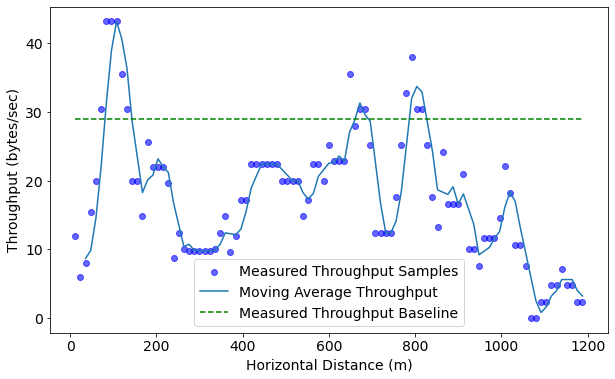

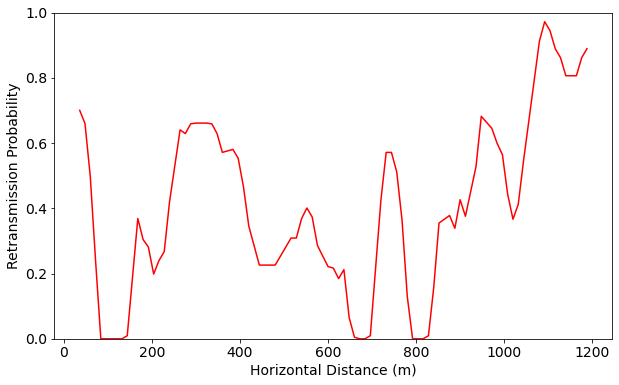

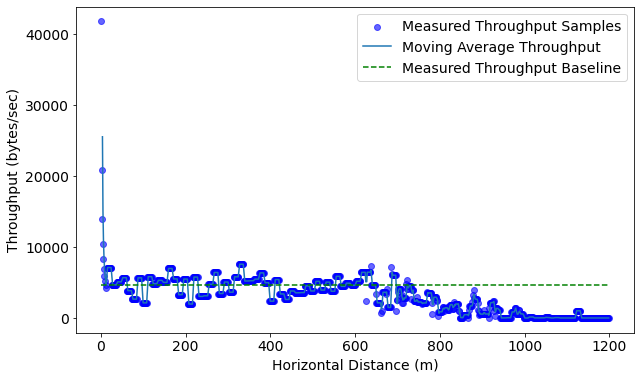

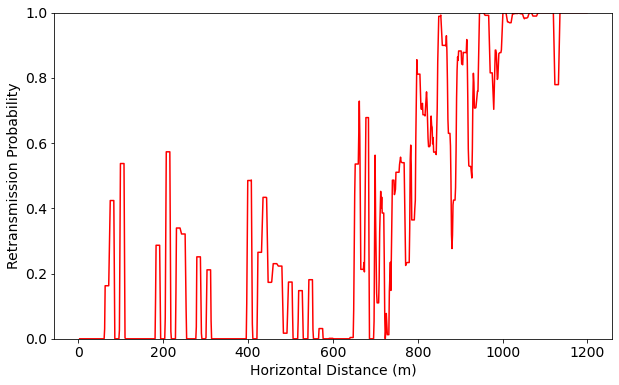

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob, os

# Get data 
sim_root_path = "/media/research-student/One Touch/FANET Datasets/DJISpark_ReBroadcast_Protocols_Test/measured_throughput_test/UAVSpeed-12_BitRate-13_Height-270_Distance-1200_Modulation-QPSK_UAVSendingInterval-1000_CounterThreshold-3"
scenario_files = glob.glob(sim_root_path + "/*.csv")
gw_throughput_file = [file for file in scenario_files if (('_GW-Throughput' in file))]
gw_throughput_df = pd.read_csv(gw_throughput_file[0])
gcs_throughput_file = [file for file in scenario_files if (('_GCS-Throughput' in file))]
gcs_throughput_df = pd.read_csv(gcs_throughput_file[0])

# Get horizontal distance data
uav_speed = 12
gw_throughput_df["Horizontal_Distance"] = gw_throughput_df["Measurement_Time"] * uav_speed
gcs_throughput_df["Horizontal_Distance"] = gcs_throughput_df["Measurement_Time"] * uav_speed

# Get moving averages
# Gateway
window_size = 3
windows_throughput = gw_throughput_df["Measured_Throughput"].rolling(window_size)
windows_hdist = gw_throughput_df["Horizontal_Distance"].rolling(window_size)
gw_th_moving_avg = windows_throughput.mean().tolist()
gw_hdist_moving_avg = windows_hdist.max().tolist()
# GCS
window_size = 3
windows_throughput = gcs_throughput_df["Measured_Throughput"].rolling(window_size)
windows_hdist = gcs_throughput_df["Horizontal_Distance"].rolling(window_size)
gcs_th_moving_avg = windows_throughput.mean().tolist()
gcs_hdist_moving_avg = windows_hdist.max().tolist()

# Plot gateway measured throughput
gwThroughputBaseline = 28.94
plt.figure(figsize=(10,6))
plt.rcParams.update({'font.size': 14})
plt.scatter(gw_throughput_df["Horizontal_Distance"], gw_throughput_df["Measured_Throughput"], c="b", alpha=0.6)
plt.plot(gw_hdist_moving_avg, gw_th_moving_avg)
plt.plot([gw_throughput_df["Horizontal_Distance"].min(), gw_throughput_df["Horizontal_Distance"].max()], [gwThroughputBaseline, gwThroughputBaseline], '--g')
plt.xlabel("Horizontal Distance (m)")
plt.ylabel("Throughput (bytes/sec)")
plt.legend(["Measured Throughput Samples", "Moving Average Throughput", "Measured Throughput Baseline"])

# Plot gateway broadcast probability
plt.figure(figsize=(10,6))
plt.rcParams.update({'font.size': 14})
plt.plot(gw_hdist_moving_avg, np.clip(1 - np.array(gw_th_moving_avg)/gwThroughputBaseline, a_min=0, a_max=1), 'r')
plt.ylim(0,1)
plt.xlabel("Horizontal Distance (m)")
plt.ylabel("Retransmission Probability")

# Plot GCS measured throughput
gcsThroughputBaseline = 4593.15
plt.figure(figsize=(10,6))
plt.rcParams.update({'font.size': 14})
plt.scatter(gcs_throughput_df["Horizontal_Distance"], gcs_throughput_df["Measured_Throughput"], c="b", alpha=0.6)
plt.plot(gcs_hdist_moving_avg, gcs_th_moving_avg)
plt.plot([gcs_throughput_df["Horizontal_Distance"].min(), gcs_throughput_df["Horizontal_Distance"].max()], [gcsThroughputBaseline, gcsThroughputBaseline], '--g')
plt.xlabel("Horizontal Distance (m)")
plt.ylabel("Throughput (bytes/sec)")
plt.legend(["Measured Throughput Samples", "Moving Average Throughput", "Measured Throughput Baseline"])

# Plot GCS broadcast probability
plt.figure(figsize=(10,6))
plt.rcParams.update({'font.size': 14})
plt.plot(gcs_hdist_moving_avg, np.clip(1 - np.array(gcs_th_moving_avg)/gcsThroughputBaseline, a_min=0, a_max=1), 'r')
plt.ylim(0,1)
plt.xlabel("Horizontal Distance (m)")
plt.ylabel("Retransmission Probability")

## Plot Comparison of Reliability under Interference Scenarios

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob, os

# Get data for fixed probability 50% - interference scenarios
FP_DATASET_INT = "/media/research-student/One Touch/FANET Datasets/DJISpark_ReBroadcast_Protocols_Interference/fixedProb-0.5_CT-3_processed"
scenario_list = [f.path for f in os.scandir(FP_DATASET_INT) if f.is_dir()] # Get list of "unique" scenarios
broadcast_metric_list = []
for scenario in scenario_list:
    # Get params of this senario
    scenario_params = scenario.split("/")[-1].split('_')
    interferenceDist = scenario_params[3].split("-")[-1]
    uavGcsInterfDist = scenario_params[-2].split("-")[-1]
    broadcast_metric_file = os.path.join(scenario, "Broadcast_Metrics.csv")
    broadcast_metric_df = pd.read_csv(broadcast_metric_file)
    dl_reliability_avg = broadcast_metric_df["Total_Reliability_DL"].mean()
    useful_packet_ratio_avg = broadcast_metric_df["Useful_Packet_Reception_Ratio_DL"].mean()

    